<h1>2D reflection and transmission against photon frequency</h1>

In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

cwd = Path().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src").exists())
sys.path.append(str(project_root))
sys.path.append(str(project_root / "2d_setup" / "scripts_experiments"))

#Local imports
from src.fiber_geometry import (
    geometry_filename,
    load_geometry_csv,
    plot_fiber_geometry,
    plot_slab_geometry,
    slab_geometry_filename,
)
from reflection_vs_frequency import result_filename, run_reflection_vs_frequency


<h2>Load the geometry</h2>

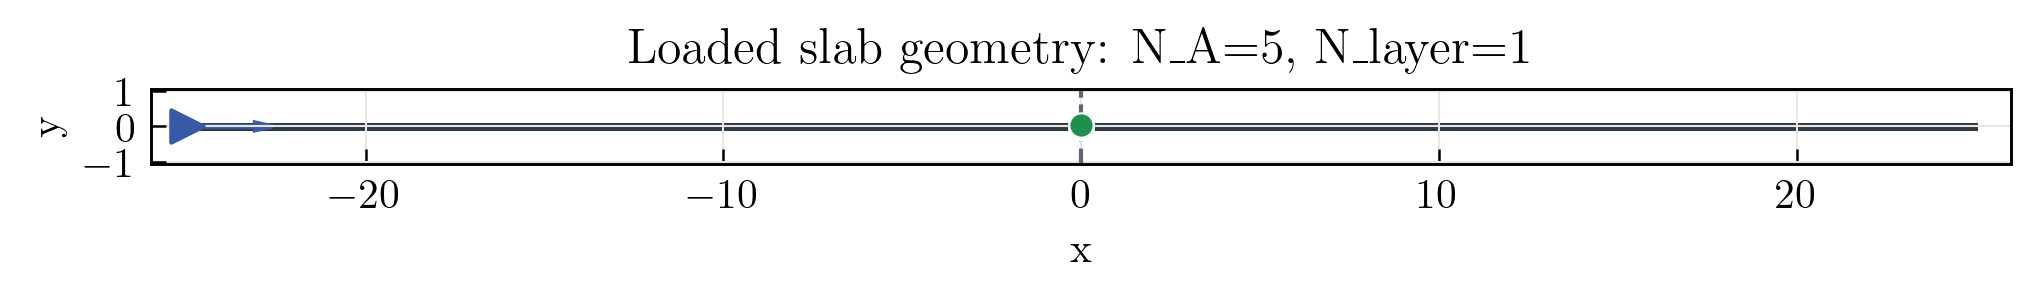

Loaded geometry from: /Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA5_NL1.csv


In [2]:
geometry_kind = "slab"  # "disk" or "slab"

N_A = 5
interface_radius = 1.5
N_layer = 1

geometry_dir = project_root / "2d_setup" / "geometries"
if geometry_kind == "disk":
    geometry_path = geometry_dir / geometry_filename(N_A, interface_radius)
elif geometry_kind == "slab":
    geometry_path = geometry_dir / slab_geometry_filename(N_A, N_layer)
else:
    raise ValueError("geometry_kind must be 'disk' or 'slab'.")

if not geometry_path.exists():
    raise FileNotFoundError(
        f"Geometry file not found: {geometry_path}. "
        "Run 2d_setup/notebooks/geometry_creation.ipynb first."
    )

geometry = load_geometry_csv(geometry_path)
atom_positions = geometry["atom_positions"]
L1 = geometry["L1"]
L2 = geometry["L2"]
loaded_geometry_kind = "slab" if geometry.get("N_layer", 0) > 0 else "disk"

fig, ax = plt.subplots(figsize=(8.0, 2.2), dpi=resol)
if loaded_geometry_kind == "disk":
    plot_fiber_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        interface_radius=geometry["interface_radius"],
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded disk geometry: N_A={geometry['N_A']}, R={geometry['interface_radius']:g}")
else:
    plot_slab_geometry(
        ax,
        L1=L1,
        L2=L2,
        atom_positions=atom_positions,
        n_layers=geometry["N_layer"],
        photon_position=(-L1 / 2, 0.0),
    )
    ax.set_title(f"Loaded slab geometry: N_A={geometry['N_A']}, N_layer={geometry['N_layer']}")
plt.show()

print(f"Loaded geometry from: {geometry_path}")

<h2>Execute the experiment</h2>

Each experiment corresponds to a given frequency window $[\Lambda_{\rm IR}, \Lambda_{\rm UV}]$.

In [5]:
#Parameters of the simulation
Omega = 10*np.pi
d = 1.0
Omega_j = Omega * np.ones(geometry['N_A'])
d_j = d * np.ones(geometry['N_A'], dtype=float)
param_atom = {'Omega_j': Omega_j, 'd_j': d_j}
param_photon_bis = {'delta_k': 0.15*np.pi}
param_time_evol = {'T': 50, 'dt': 0.05}

#Define an array of frequencies around the matter resonance
nb_freq = 21
omega_init_tab = np.linspace(Omega - 2*abs(d)**2,
                            Omega + 2*abs(d)**2,
                            nb_freq)

#Assess reflection/transmission for different frequency windows
frequency_windows = [
    (0*pi, 20*pi),
    (0*pi, 14*pi),
    (8*pi, 14*pi),
    (9*pi, 11*pi)
]

Run the experiment for each frequency window.

In [6]:
for i in range(len(frequency_windows)):
    index_experiment = i + 1
    print("Running frequency window number ", index_experiment, " out of ", len(frequency_windows))
    cutoffs = {'ir_cutoff': frequency_windows[i][0], 'uv_cutoff': frequency_windows[i][1]}

    frequency_values, final_reflection_tab, final_transmission_tab = run_reflection_vs_frequency(
        param_photon_bis,
        param_atom,
        param_time_evol,
        omega_init_tab,
        cutoffs,
        geometry,
        index_experiment=index_experiment,
        progress=True,
    )

Running frequency window number  1  out of  4


100%|██████████| 21/21 [00:15<00:00,  1.33it/s]


Running frequency window number  2  out of  4


100%|██████████| 21/21 [00:04<00:00,  4.86it/s]


Running frequency window number  3  out of  4


100%|██████████| 21/21 [00:01<00:00, 10.60it/s]


Running frequency window number  4  out of  4


100%|██████████| 21/21 [00:01<00:00, 20.52it/s]


<h2>Plot the results</h2>

$[0.0\pi,20.0\pi]$: R+T = [1.002936, 1.003011] (mean = 1.002987)
$[0.0\pi,14.0\pi]$: R+T = [0.999977, 1.000169] (mean = 1.000092)
$[8.0\pi,14.0\pi]$: R+T = [0.999951, 1.000000] (mean = 0.999982)
$[9.0\pi,11.0\pi]$: R+T = [0.999974, 1.000000] (mean = 0.999996)


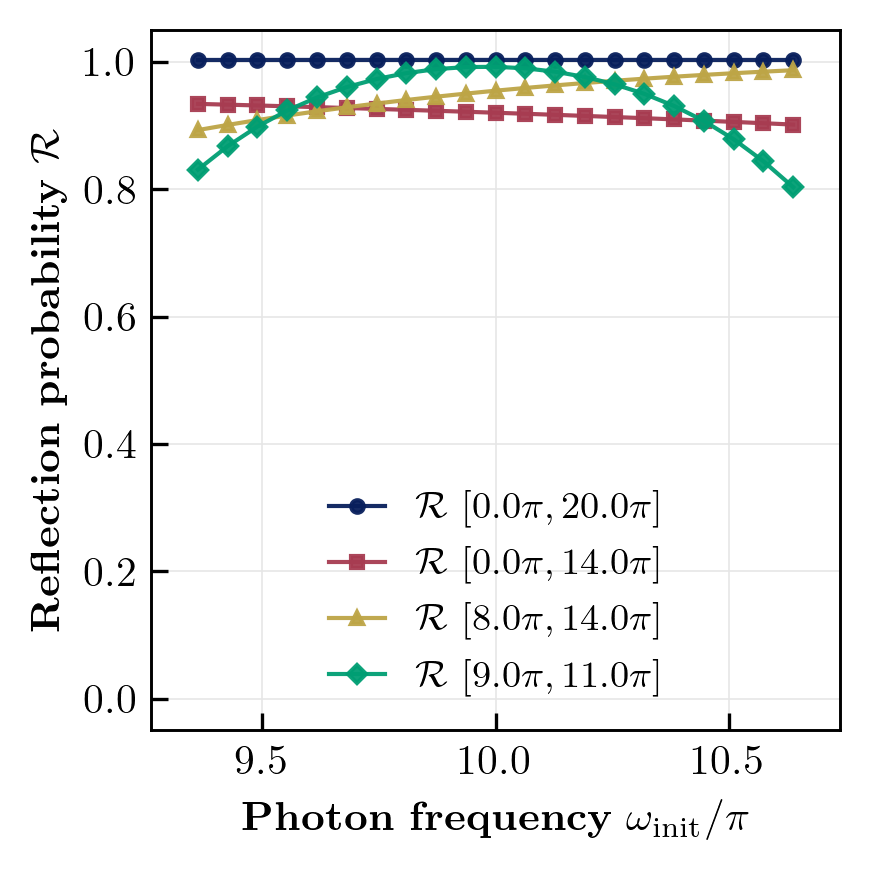

In [8]:
data_dir = project_root / "2d_setup" / "results" / "csv_files" / "reflection_vs_frequency"

colors_reflection = ["#081f5c", "#a73c51", "#bda546", "#009E73"]
markers_reflection = ["o", "s", "^", "D"]

fig, ax = plt.subplots(figsize=(3, 3), dpi=resol)

for index_experiment in range(1, len(frequency_windows) + 1):
    ir_cutoff = frequency_windows[index_experiment - 1][0]
    uv_cutoff = frequency_windows[index_experiment - 1][1]
    data_file = data_dir / result_filename(geometry, index_experiment)
    df = pd.read_csv(data_file)

    photon_frequency_tab = df["photon_frequency_tab"].to_numpy()
    reflection_tab = df["final_reflection_tab"].to_numpy()
    transmission_tab = df["final_transmission_tab"].to_numpy()
    reflection_plus_transmission = reflection_tab + transmission_tab

    label_window = rf"$[{ir_cutoff/np.pi:.1f}\pi,{uv_cutoff/np.pi:.1f}\pi]$"
    color = colors_reflection[index_experiment - 1]
    marker = markers_reflection[index_experiment - 1]

    print(
        rf"{label_window}: R+T = "
        f"[{reflection_plus_transmission.min():.6f}, {reflection_plus_transmission.max():.6f}] "
        f"(mean = {reflection_plus_transmission.mean():.6f})"
    )

    ax.plot(
        photon_frequency_tab / np.pi,
        reflection_tab,
        marker=marker,
        markersize=3,
        color=color,
        linewidth=1.0,
        alpha=0.95,
        label=rf"$\mathcal{{R}}$ {label_window}",
        zorder=3,
    )

omega_min_pi = np.min(omega_init_tab) / np.pi
omega_max_pi = np.max(omega_init_tab) / np.pi
ax.set_xlim(omega_min_pi - 0.1, omega_max_pi + 0.1)

ax.set_xlabel(r"\textbf{Photon frequency} $\omega_{\rm init}/\pi$", fontsize=10)
ax.set_ylabel(r"\textbf{Reflection probability} $\mathcal{R}$", fontsize=10)
ax.set_ylim(-0.05, 1.05)
ax.grid(color="0.9", linestyle="-", linewidth=0.4)
ax.tick_params(axis="both", which="major", length=4, width=0.8, labelsize=10)
ax.legend(prop={"size": 9}, loc="lower center", frameon=False, ncol=1, handlelength=1.5)
plt.tight_layout()
plt.show()
